### Homework 5: Question search engine

Remeber week01 where you used GloVe embeddings to find related questions? That was.. cute, but far from state of the art. It's time to really solve this task using context-aware embeddings.

__Warning:__ this task assumes you have seen `seminar.ipynb`!

In [17]:
# %pip install --upgrade transformers datasets accelerate deepspeed
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import datasets
from tqdm import tqdm

### Load data and model

In [11]:
qqp = datasets.load_dataset('SetFit/qqp')
print('\n')
print("Sample[0]:", qqp['train'][0])
print("Sample[3]:", qqp['train'][3])

Repo card metadata block was not found. Setting CardData to empty.




Sample[0]: {'text1': 'How is the life of a math student? Could you describe your own experiences?', 'text2': 'Which level of prepration is enough for the exam jlpt5?', 'label': 0, 'idx': 0, 'label_text': 'not duplicate'}
Sample[3]: {'text1': 'What can one do after MBBS?', 'text2': 'What do i do after my MBBS ?', 'label': 1, 'idx': 3, 'label_text': 'duplicate'}


In [3]:
model_name = "gchhablani/bert-base-cased-finetuned-qqp"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

/home/akash/.local/lib/python3.8/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


### Tokenize the data

In [12]:
MAX_LENGTH = 128
def preprocess_function(examples):
    result = tokenizer(
        examples['text1'], examples['text2'],
        padding='max_length', max_length=MAX_LENGTH, truncation=True
    )
    result['label'] = examples['label']
    return result

qqp_preprocessed = qqp.map(preprocess_function, batched=True)

Map:   0%|          | 0/363846 [00:00<?, ? examples/s]

NameError: name 'tokenizer' is not defined

In [7]:
print(repr(qqp_preprocessed['train'][0]['input_ids'])[:100], "...")

[101, 1731, 1110, 1103, 1297, 1104, 170, 12523, 2377, 136, 7426, 1128, 5594, 1240, 1319, 5758, 136,  ...


### Task 1: evaluation (1 point)

We randomly chose a model trained on QQP - but is it any good?

One way to measure this is with validation accuracy - which is what you will implement next.

Here's the interface to help you do that:

In [10]:
val_set = qqp_preprocessed['validation']
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=1, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=8
)

In [9]:
for batch in val_loader:
     break  # here be your training code
print("Sample batch:", batch)

with torch.no_grad():
    predicted = model(
      input_ids=batch['input_ids'],
      attention_mask=batch['attention_mask'],
      token_type_ids=batch['token_type_ids']
    )
    

print('\nPrediction (probs):', torch.softmax(predicted.logits, dim=1).data.numpy())

Sample batch: {'labels': tensor([0]), 'idx': tensor([0]), 'input_ids': tensor([[  101,  2009,  1132,  2170,   118,  4038,  1177,  2712,   136,   102,
          2009,  1132,  1117, 10224,  4724,  1177,  2712,   136,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,   

__Your task__ is to measure the validation accuracy of your model.
Doing so naively may take several hours. Please make sure you use the following optimizations:

- run the model on GPU with no_grad
- using batch size larger than 1
- use optimize data loader with num_workers > 1
- (optional) use [mixed precision](https://pytorch.org/docs/stable/notes/amp_examples.html)


In [ ]:
def validate(val_loader, model):
    correct_pred = 0
    samples = 0
    for batch in val_loader:
        with torch.no_grad():    
            predicted = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
            )
            target = batch['labels'].to(device)
            correct_pred += torch.sum(target == torch.argmax(predicted.logits, dim=-1))
            samples += batch['labels'].shape[0]
        
    return correct_pred / samples

In [48]:
model = model.to('cuda')
val_set = qqp_preprocessed['validation']
batch_size = 64
n_workers = 8
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=batch_size, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=n_workers
)

validate(val_loader, model)

  0%|                                                                                                                                 | 0/632 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoi

In [50]:
assert 0.9 < accuracy < 0.91

### Task 2: train the model (4 points)

For this task, you have two options:

__Option A:__ fine-tune your own model. You are free to choose any model __except for the original BERT.__ We recommend [DeBERTa-v3](https://huggingface.co/microsoft/deberta-v3-base). Better yet, choose the best model based on public benchmarks (e.g. [GLUE](https://gluebenchmark.com/)).

You can write the training code manually or use transformers.Trainer (see [this example](https://github.com/huggingface/transformers/blob/main/examples/pytorch/text-classification)). Please make sure that your model's accuracy is at least __comparable__ with the above example for BERT.


__Option B:__ compare at least 3 pre-finetuned models (in addition to the above BERT model). For each model, report (1) its accuracy, (2) its speed, measured in samples per second in your hardware setup and (3) its size in megabytes. Please take care to compare models in equal setting, e.g. same CPU / GPU. Compile your results into a table and write a short (~half-page on top of a table) report, summarizing your findings.

In [142]:
# %pip install --upgrade transformers datasets accelerate deepspeed
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import datasets
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
%matplotlib inline
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"]="python" # w/a for loading a model

In [2]:
qqp = datasets.load_dataset('SetFit/qqp')
print('\n')
print("Sample[0]:", qqp['train'][0])
print("Sample[3]:", qqp['train'][3])

Repo card metadata block was not found. Setting CardData to empty.




Sample[0]: {'text1': 'How is the life of a math student? Could you describe your own experiences?', 'text2': 'Which level of prepration is enough for the exam jlpt5?', 'label': 0, 'idx': 0, 'label_text': 'not duplicate'}
Sample[3]: {'text1': 'What can one do after MBBS?', 'text2': 'What do i do after my MBBS ?', 'label': 1, 'idx': 3, 'label_text': 'duplicate'}


In [151]:
my_model_name = "microsoft/deberta-v3-base"
my_tokenizer = transformers.AutoTokenizer.from_pretrained(my_model_name)
my_model = transformers.AutoModelForSequenceClassification.from_pretrained(my_model_name, num_labels=2)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
MAX_LENGTH = 128
def preprocess_function(examples):
    result = my_tokenizer(
        examples['text1'], examples['text2'],
        padding='max_length', max_length=MAX_LENGTH, truncation=True
    )
    result['label'] = examples['label']
    return result

qqp_preprocessed = qqp.map(preprocess_function, batched=True)

Map:   0%|          | 0/363846 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Map:   0%|          | 0/40430 [00:00<?, ? examples/s]

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]

In [6]:
val_set = qqp_preprocessed['validation']
batch_size = 64
n_workers = 8
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=batch_size, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=n_workers
)

In [152]:
train_set = qqp_preprocessed['train']
batch_size = 64
n_workers = 16
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True, collate_fn=transformers.default_data_collator, num_workers=n_workers
)
opt = torch.optim.AdamW(my_model.parameters(), lr=5e-6, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(opt, mode='min', patience=2, factor=0.5, verbose=True)

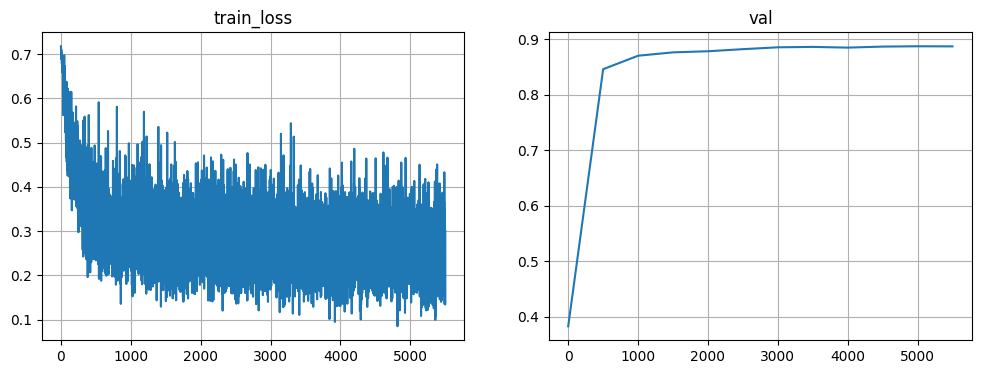

Mean loss=0.251


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5686/5686 [57:34<00:00,  1.65it/s]


In [157]:
device = 'cuda'
metrics = {'train_loss': [], 'val': [] }
my_model = my_model.to(device)
my_model.train()
for step, batch in enumerate(tqdm(train_loader)):
    opt.zero_grad()
    predicted = my_model(
        input_ids=batch['input_ids'].to(device),
        attention_mask=batch['attention_mask'].to(device)
    )
    target = batch['labels'].to(device)
    target = target.long()
    loss = F.cross_entropy(predicted.logits.to(device), target)
    loss.backward()
    opt.step()
    
    metrics['train_loss'].append((step, loss.item()))
    if step % 500 == 0:
        with torch.no_grad():
            val_acc = validate(val_loader, my_model)
            scheduler.step(val_acc)
            metrics['val'].append((step, val_acc.detach().cpu().numpy()))
        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

In [83]:
validate(val_loader, my_model)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

tensor(0.4426, device='cuda:2')

### Task 3: try the full pipeline (1 point)

Finally, it is time to use your model to find duplicate questions.
Please implement a function that takes a question and finds top-5 potential duplicates in the training set. For now, it is fine if your function is slow, as long as it yields correct results.

Showcase how your function works with at least 5 examples.

In [ ]:
import heapq

In [364]:
def find_most_probable_sentence(model, tokenizer, qqp_preprocessed, sentence):
    top_five = []
    dataset_len = len(qqp_preprocessed['train']['text1'])
    
    for i in tqdm(range(dataset_len // batch_size + 1)): # own dataloader :)
        text1 = qqp_preprocessed['train']['text1'][i * batch_size : min(i * batch_size + batch_size, dataset_len)]
        text2 = qqp_preprocessed['train']['text2'][i * batch_size : min(i * batch_size + batch_size, dataset_len)]
        for text in (text1, text2):
            with torch.no_grad():
                tokens = tokenizer(text, [sentence] * len(text), 
                                   padding='max_length', max_length=MAX_LENGTH, 
                                   truncation=True, return_tensors='pt')
                
                predicted = model(
                    input_ids=tokens['input_ids'].to(device),
                    attention_mask=tokens['attention_mask'].to(device),)
                
                for j, logit in enumerate(predicted.logits):
                    probs = torch.softmax(logit.cpu(), dim=0).detach().numpy()
                    if top_five and probs[1] < top_five[0][0]:
                        continue
                    if text[j] in (top_text for _, top_text in top_five): # do not save same text
                        continue
                    if len(top_five) == 5:
                       heapq.heappop(top_five)

                    heapq.heappush(top_five, (probs[1], text[j]) )
    top_five.sort(reverse=True)
    return top_five

In [360]:
# pipeline_val_set = qqp_preprocessed_pipeline['validation']
# batch_size = 128
# n_workers = 8
# pipeline_val_loader = torch.utils.data.DataLoader(
#     val_set, batch_size=batch_size, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=n_workers
# )

# def find_most_probable_sentence_v2(model, pipeline_val_loader):
#     top_five = []
#     for batch in tqdm(pipeline_val_loader):
#         with torch.no_grad():
#             predicted = model(
#                 input_ids=batch['input_ids'].to(device),
#                 attention_mask=batch['attention_mask'].to(device),
#             )
#             for i, logit in enumerate(predicted.logits):
#                 probs = torch.softmax(logit.cpu(), dim=0).data.numpy()
#             if top_five and probs[1] < top_five[0][0]:
#                 continue
#             if len(top_five) == 5:
#                 heapq.heappop(top_five)
#             heapq.heappush(top_five, (probs[1], my_tokenizer.convert_tokens_to_string(my_tokenizer.batch_decode(batch['input_ids'][i]))))
#     top_five.sort(reverse=True) 
#     return top_five

In [365]:
my_model.eval()
sentences = ['How can I lose some weight?', 'What is the purpose of life?', 'Who is the best sportsman?', 'Why are people so rude?', 'What should I do with my life?']
top_fives = []
for sentence in sentences:
    top_five = find_most_probable_sentence(my_model, my_tokenizer, qqp_preprocessed, sentence)
    top_fives.append(top_five)
    print (f'Original sentence : {sentence}')
    print (f'Top five similar sentences: {top_five}')

100%|███████████████████████████████████████| 2843/2843 [58:30<00:00,  1.23s/it]


Original sentence : How can I lose some weight?
Top five similar sentences: [(0.98680323, 'How can I loose fat?'), (0.985388, 'What are the best way of loose the weight?'), (0.9852036, 'How can I lose weight ?'), (0.9850691, 'How do I loose weight?'), (0.9845589, 'What can I do to lose weight?')]


100%|███████████████████████████████████████| 2843/2843 [58:37<00:00,  1.24s/it]


Original sentence : What is the purpose of life?
Top five similar sentences: [(0.9920887, "What's the purpose of life?"), (0.9910047, 'What is purpose of life?'), (0.99052423, 'What is the purpose of life ?'), (0.99032277, 'What is the purpose of life?'), (0.98823345, "What is life's purpose?")]


100%|███████████████████████████████████████| 2843/2843 [58:35<00:00,  1.24s/it]


Original sentence : Who is the best sportsman?
Top five similar sentences: [(0.96351576, 'Who is the best ever sportsman?'), (0.9172417, 'What is height og SSC CGL preparation what is height of SSC CGL preparation?'), (0.88168895, 'Who is the best sports person in the world till now?'), (0.86838025, 'Does dark energy make the Big Bang superfluous? Does dark energy make the Big Bang incorrect?'), (0.86168087, 'What is your impression of China? 你对中国的印象如何？')]


100%|███████████████████████████████████████| 2843/2843 [58:25<00:00,  1.23s/it]


Original sentence : Why are people so rude?
Top five similar sentences: [(0.93586385, 'Why are people generally rude?'), (0.9323939, 'What is height og SSC CGL preparation what is height of SSC CGL preparation?'), (0.9274311, 'Does dark energy make the Big Bang superfluous? Does dark energy make the Big Bang incorrect?'), (0.9083695, 'Why Central Govt banned old 500 and 1000 Rs note, but issued new 500 and 2000 Rs note?'), (0.90835565, 'Why does 500 and 1000 Rs notes banned by GOI and new notes of 500 and 2000 are issued?')]


100%|███████████████████████████████████████| 2843/2843 [58:19<00:00,  1.23s/it]

Original sentence : What should I do with my life?
Top five similar sentences: [(0.9466407, 'How should I spend my life?'), (0.9294976, 'What should I do in life?'), (0.92359704, 'What is height og SSC CGL preparation what is height of SSC CGL preparation?'), (0.91476715, 'What I should do with my life?'), (0.9038868, 'What should I do with my life?')]


__Bonus:__ for bonus points, try to find a way to run the function faster than just passing over all questions in a loop. For isntance, you can form a short-list of potential candidates using a cheaper method, and then run your tranformer on that short list. If you opted for this solution, please keep both the original implementation and the optimized one - and explain briefly what is the difference there.